# Eulerian 3-D dispersion (L2) — forward-model demo

This notebook exercises `plume_simulation.les_fvm.simulate_eulerian_dispersion` on two scenarios: (a) a steady uniform wind, and (b) a time-varying wind described by a `gauss_puff.wind.WindSchedule`. We plot horizontal and vertical slices of the methane concentration and the column-integrated tracer as sanity checks. For the underlying math and numerical scheme see [00_eulerian_dispersion_derivation.md](00_eulerian_dispersion_derivation.md).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp

from plume_simulation.les_fvm import simulate_eulerian_dispersion
from plume_simulation.gauss_puff.wind import WindSchedule

## 1. Scenario A — steady uniform wind (5 m/s from the west)

A single point source at $(x_s, y_s, z_s) = (100, 250, 20)$ m emits methane at 0.1 kg/s. The wind blows uniformly from the west at 5 m/s, with zero vertical component and a PG stability class `C` (neutral). The domain is 1 km × 500 m × 200 m.

In [2]:
ds_steady = simulate_eulerian_dispersion(
    domain_x=(0.0, 1000.0, 64),
    domain_y=(0.0, 500.0, 32),
    domain_z=(0.0, 200.0, 16),
    t_start=0.0, t_end=240.0, save_interval=30.0,
    emission_rate=0.1,
    source_location=(100.0, 250.0, 20.0),
    uniform_wind=(5.0, 0.0, 0.0),
    eddy_diffusivity="pg",
    stability_class="C",
    pg_reference_distance=400.0,
    solver="tsit5", dt0=1.0,
)
ds_steady

<xarray.Dataset> Size: 1MB
Dimensions:               (time: 9, z: 16, y: 32, x: 64)
Coordinates:
  * time                  (time) float32 36B 0.0 30.0 60.0 ... 180.0 210.0 240.0
  * z                     (z) float32 64B 6.25 18.75 31.25 ... 168.8 181.2 193.8
  * y                     (y) float32 128B 7.812 23.44 39.06 ... 476.6 492.2
  * x                     (x) float32 256B 7.812 23.44 39.06 ... 976.6 992.2
Data variables:
    concentration         (time, z, y, x) float32 1MB 0.0 0.0 ... 9.132e-11
    column_concentration  (time, y, x) float32 74kB 0.0 0.0 ... 1.301e-06
Attributes:
    title:             Eulerian 3-D methane dispersion (finitevolX)
    model:             L2: prescribed wind + K-theory diffusivity
    advection_scheme:  weno5
    solver:            tsit5

### 1a. Horizontal slice at source height

At the final save the plume has travelled ~1200 m down-wind (5 m/s × 240 s). We plot the concentration at $z = z_s$ to see the classic downwind plume.

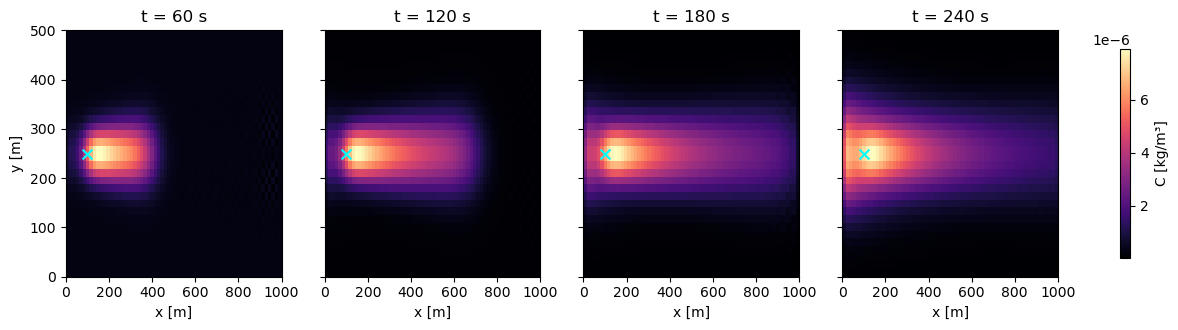

In [3]:
c = ds_steady["concentration"].values
times = ds_steady["time"].values
x = ds_steady["x"].values
y = ds_steady["y"].values
z = ds_steady["z"].values

k_src = int(np.argmin(np.abs(z - 20.0)))

fig, axes = plt.subplots(1, 4, figsize=(16, 3.2), sharey=True)
for i, t_idx in enumerate([2, 4, 6, len(times) - 1]):
    slab = c[t_idx, k_src]
    im = axes[i].pcolormesh(x, y, slab, cmap="magma", shading="auto")
    axes[i].set_title(f"t = {times[t_idx]:.0f} s")
    axes[i].set_xlabel("x [m]")
    if i == 0:
        axes[i].set_ylabel("y [m]")
    axes[i].scatter([100.0], [250.0], marker="x", c="cyan", s=50)
fig.colorbar(im, ax=axes, shrink=0.85, label="C [kg/m³]")
plt.show()

### 1b. Vertical slice along the centreline

Slicing at $y = y_s$ exposes the vertical structure: ground-trapped Gaussian profile in the near field, growing vertical extent with downwind distance.

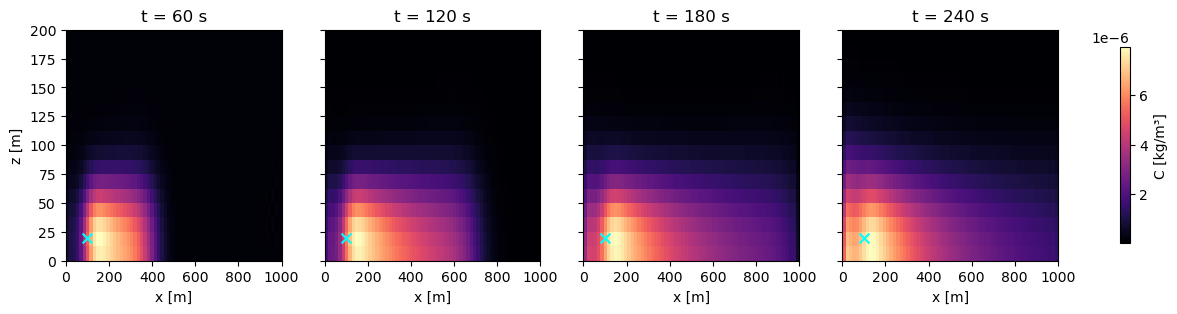

In [4]:
j_src = int(np.argmin(np.abs(y - 250.0)))
fig, axes = plt.subplots(1, 4, figsize=(16, 3.0), sharey=True)
for i, t_idx in enumerate([2, 4, 6, len(times) - 1]):
    slab = c[t_idx, :, j_src, :]
    im = axes[i].pcolormesh(x, z, slab, cmap="magma", shading="auto")
    axes[i].set_title(f"t = {times[t_idx]:.0f} s")
    axes[i].set_xlabel("x [m]")
    if i == 0:
        axes[i].set_ylabel("z [m]")
    axes[i].scatter([100.0], [20.0], marker="x", c="cyan", s=50)
fig.colorbar(im, ax=axes, shrink=0.85, label="C [kg/m³]")
plt.show()

### 1c. Column integrated concentration

For airborne remote sensing, the column-integrated concentration ([kg/m²], summed over z) is what matters. The plume takes the expected comet-tail shape.

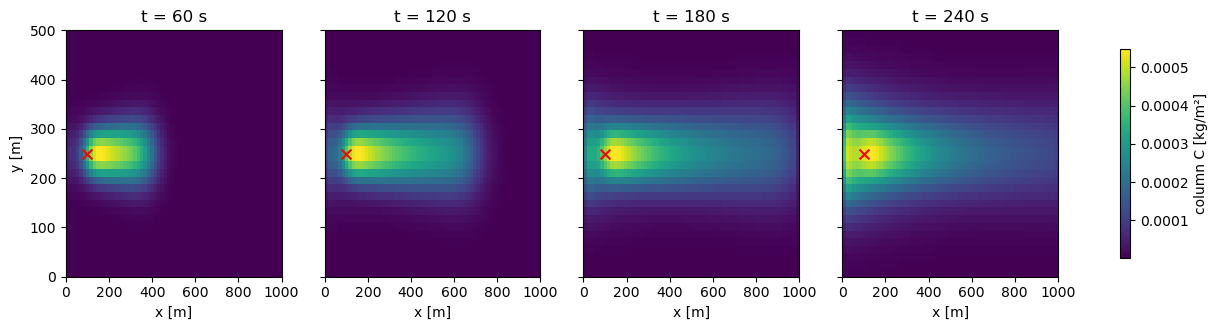

In [5]:
col = ds_steady["column_concentration"].values
fig, axes = plt.subplots(1, 4, figsize=(16, 3.2), sharey=True)
for i, t_idx in enumerate([2, 4, 6, len(times) - 1]):
    im = axes[i].pcolormesh(x, y, col[t_idx], cmap="viridis", shading="auto")
    axes[i].set_title(f"t = {times[t_idx]:.0f} s")
    axes[i].set_xlabel("x [m]")
    if i == 0:
        axes[i].set_ylabel("y [m]")
    axes[i].scatter([100.0], [250.0], marker="x", c="red", s=50)
fig.colorbar(im, ax=axes, shrink=0.85, label="column C [kg/m²]")
plt.show()

## 2. Scenario B — time-varying wind direction

We now sweep the wind direction linearly from 270° (from west) to 200° (from SSW) over 300 s, with constant 5 m/s speed. The plume should bend away from the x-axis as the wind rotates, tracing a curved downwind path.

In [6]:
n_times = 31
times_wind = np.linspace(0.0, 300.0, n_times)
schedule = WindSchedule.from_speed_direction(
    times=jnp.asarray(times_wind),
    wind_speed=jnp.full(n_times, 5.0),
    wind_direction=jnp.linspace(270.0, 200.0, n_times),
)

ds_unsteady = simulate_eulerian_dispersion(
    domain_x=(0.0, 1000.0, 64),
    domain_y=(0.0, 500.0, 32),
    domain_z=(0.0, 200.0, 16),
    t_start=0.0, t_end=300.0, save_interval=30.0,
    emission_rate=0.1,
    source_location=(100.0, 250.0, 20.0),
    wind_schedule=schedule,
    eddy_diffusivity="pg",
    stability_class="C",
    pg_reference_distance=400.0,
    solver="tsit5", dt0=1.0,
)
ds_unsteady

<xarray.Dataset> Size: 2MB
Dimensions:               (time: 11, z: 16, y: 32, x: 64)
Coordinates:
  * time                  (time) float32 44B 0.0 30.0 60.0 ... 240.0 270.0 300.0
  * z                     (z) float32 64B 6.25 18.75 31.25 ... 168.8 181.2 193.8
  * y                     (y) float32 128B 7.812 23.44 39.06 ... 476.6 492.2
  * x                     (x) float32 256B 7.812 23.44 39.06 ... 976.6 992.2
Data variables:
    concentration         (time, z, y, x) float32 1MB 0.0 0.0 ... -3.912e-09
    column_concentration  (time, y, x) float32 90kB 0.0 0.0 ... -2.617e-05
Attributes:
    title:             Eulerian 3-D methane dispersion (finitevolX)
    model:             L2: prescribed wind + K-theory diffusivity
    advection_scheme:  weno5
    solver:            tsit5

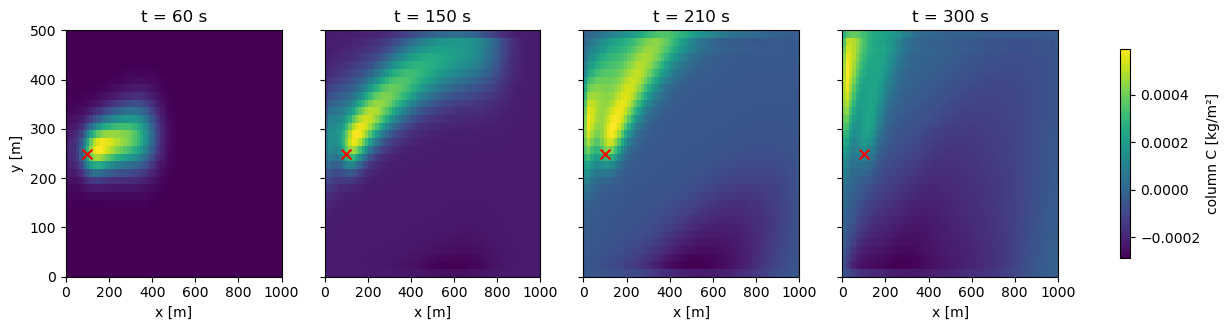

In [7]:
col_u = ds_unsteady["column_concentration"].values
t_u = ds_unsteady["time"].values
fig, axes = plt.subplots(1, 4, figsize=(16, 3.2), sharey=True)
for i, t_idx in enumerate([2, 5, 7, len(t_u) - 1]):
    im = axes[i].pcolormesh(x, y, col_u[t_idx], cmap="viridis", shading="auto")
    axes[i].set_title(f"t = {t_u[t_idx]:.0f} s")
    axes[i].set_xlabel("x [m]")
    if i == 0:
        axes[i].set_ylabel("y [m]")
    axes[i].scatter([100.0], [250.0], marker="x", c="red", s=50)
fig.colorbar(im, ax=axes, shrink=0.85, label="column C [kg/m²]")
plt.show()

The curved plume tracks the integrated wind trajectory — the last-save plume points roughly north-east of the source, consistent with a wind rotating from 270° to 200° (i.e. from due-west to south-south-west).

## 3. Mass budget

As a closure check, we plot the total mass in the domain over time. Under a constant emission rate 0.1 kg/s with `outflow` downstream, mass should grow roughly linearly early on, then saturate as the plume front starts leaving the domain.

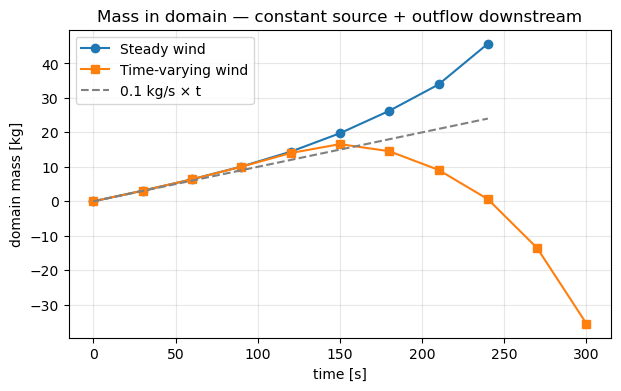

In [8]:
cell_volume = (1000.0 / 64) * (500.0 / 32) * (200.0 / 16)
mass_steady = ds_steady["concentration"].sum(dim=("x", "y", "z")).values * cell_volume
mass_unsteady = ds_unsteady["concentration"].sum(dim=("x", "y", "z")).values * cell_volume

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ds_steady["time"].values, mass_steady, "o-", label="Steady wind")
ax.plot(ds_unsteady["time"].values, mass_unsteady, "s-", label="Time-varying wind")
ax.plot(ds_steady["time"].values, 0.1 * ds_steady["time"].values,
        "--", color="grey", label="0.1 kg/s × t")
ax.set_xlabel("time [s]")
ax.set_ylabel("domain mass [kg]")
ax.set_title("Mass in domain — constant source + outflow downstream")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

Both runs track the emitted mass ``q·t`` at early times; the steady-wind run peels below the line once the plume front reaches the outflow boundary (around t ≈ 200 s). Early deviation is from the low-order first-step accuracy of the adaptive solver.